In [1]:
#!/usr/bin/env python
# coding: utf-8
"""
Community-detection check against known earthquake sequences – Italy (1985-2025)

Do the detected communities recover real, documented seismic sequences? We
isolate well-known Italian sequences (L'Aquila 2009, Amatrice-Norcia 2016,
Emilia 2012, Umbria-Marche 1997) by a space-time box around each mainshock,
then test whether community detection groups each sequence's events into a
single community instead of scattering them.
"""

import logging
from pathlib import Path

import networkx as nx
import pandas as pd
import plotly.io as pio
import seaborn as sns
from shapely.geometry import Point, Polygon

from src.network_custom import build_abe_suzuki_network_custom_hybrid
from src.network import discretize_space_3d
from src.community_custom import (
    run_louvain_directed_hybrid,
    run_infomap_hybrid,
    plot_community_geo_hybrid,
)
from src.known_sequences import (
    label_known_sequences,
    sequence_community_concentration,
    plot_sequence_community_geo,
)
from src.plotutils import setup_matplotlib, setup_presentation_style, configure_saves

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore[assignment]

logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")
# Silence chatty third-party loggers (Kaleido/Chromium PDF export spam, matplotlib
# font cache, PIL image debug, asyncio cleanup) – keep our own INFO messages visible.
for _noisy in ("kaleido", "choreographer", "logistro", "matplotlib",
               "PIL", "urllib3", "asyncio"):
    logging.getLogger(_noisy).setLevel(logging.WARNING)
sns.set_theme(style="whitegrid")
pio.renderers.default = "notebook"

# ── Global configuration ─────────────────────────────────────────────────────
DATA_DIR    = Path("data/INGV")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
(RESULTS_DIR / "data").mkdir(exist_ok=True)
CUT_YEAR   = 1985
TARGET_CRS = "epsg:32632"             # UTM Zone 32N – Italy

# Days *before* each mainshock to include in its space-time box (catches
# foreshocks); the aftershock window length is the per-sequence ``days`` key below.
PRE_DAYS = 30

# Network construction parameters – same hybrid configuration as the main analysis.
CELL_SIZE_KM         = 30          # spatial cell side (km)
SPATIAL_THRESHOLD_KM = 300.0       # max Δr (km) between consecutive EQ to keep a link
TIME_THRESHOLD_SEC   = 72 * 3600   # max Δt (s) between consecutive EQ to keep a link
ALPHA                = 0.7         # magnitude scaling exponent
TAU                  = 1 * 86400.0 # temporal decay scale (s)
R0                   = 50.0        # spatial decay scale (km)

# NET_LABEL is the optional title suffix (kept empty – see network_custom_hybrid.py);
# NET_TAG is the filename slug for saved figures.
NET_LABEL = ""
NET_TAG   = f"italy_{CELL_SIZE_KM}km"

_IT_BOUNDS = dict(west=3, east=22, south=34, north=48)
MAP_WIDTH  = 770
MAP_HEIGHT = 700

setup_matplotlib()
# Slide-ready style for presentation; set PRESENTATION_STYLE = False for normal screen / print style.
PRESENTATION_STYLE = True
if PRESENTATION_STYLE:
    setup_presentation_style()
configure_saves(True, True, RESULTS_DIR / "figures" / "italy" / "known_eq")

# Known Italian sequences, defined as space-time boxes around each mainshock.
# Mainshock times / boxes follow the conventions in ITALY_preanalysis.py.
SEQUENCES = [
    {"name": "Umbria-Marche 1997",
     "mainshock_time": pd.to_datetime("1997-09-26 00:33:00", utc=True),
     "days": 60, "lat_range": (42.7, 43.4), "lon_range": (12.5, 13.3)},
    {"name": "L'Aquila 2009",
     "mainshock_time": pd.to_datetime("2009-04-06 01:32:40.4", utc=True),
     "days": 50, "lat_range": (41.5, 43.0), "lon_range": (12.5, 14.0)},
    {"name": "Emilia 2012",
     "mainshock_time": pd.to_datetime("2012-05-20 02:03:52", utc=True),
     "days": 50, "lat_range": (44.6, 45.3), "lon_range": (10.7, 11.9)},
    {"name": "Amatrice-Norcia 2016",
     "mainshock_time": pd.to_datetime("2016-08-24 01:36:32", utc=True),
     "days": 120, "lat_range": (42.0, 43.5), "lon_range": (12.5, 14.0)},
]

DETECTION_METHODS = [
    ("Louvain", lambda G: run_louvain_directed_hybrid(G, resolution=1.0)),
    ("InfoMap", lambda G: run_infomap_hybrid(G, directed=True, seed=42)),
]

INFO  Presentation style ON (font=CMU Sans Serif, light theme, projection sizes)
INFO  Figure saving ON → results/figures/italy/known_eq  (PDF=True JPG=True)


## The Idea

A partition is physical only if its communities are real. We isolate four documented
Italian sequences by a **space-time box** around each mainshock and test whether community
detection **recovers** each as a single community. Two measures per sequence:
- **purity** – largest share of the sequence's events in one community ($\to 1$: recovered).
- **normalised entropy** – spread across communities ($0$ one community, $1$ scattered).

Directed Louvain (structural) and InfoMap (flow-based) are both checked.

## Data Loading

INGV catalog, $\text{year} \geq$ ``CUT_YEAR``, cropped to the Italian polygon – one event
set shared by the sequence boxes and the per-event community lookup.

In [2]:
print("Loading Italy earthquake catalog...")
df = pd.read_csv(DATA_DIR / "italy_earthquakes_1985_2025.csv")
df["time"] = pd.to_datetime(df["time"], utc=True)
df_net = (
    df[df["time"].dt.year >= CUT_YEAR]
    .sort_values("time")
    .reset_index(drop=True)
)

_ITALY_POLYGON = Polygon([
    (13.5, 44.5), (19.0, 41.2), (19.0, 35.6), (11.7, 35.5), (11.6, 37.9),
    (7.2, 38.0), (7.2, 42.6), (5.2, 45.5), (11.6, 48.4), (16.0, 46.7), (13.5, 44.5),
])
df_net = df_net[df_net.apply(
    lambda r: _ITALY_POLYGON.contains(Point(r["longitude"], r["latitude"])), axis=1
)].reset_index(drop=True)
print(f"After polygon filter: {len(df_net):,} earthquakes")

Loading Italy earthquake catalog...
After polygon filter: 209,680 earthquakes


## Isolate Known Sequences

Discretise at the network cell size (each event gets the ``cell_id`` of its network node),
then tag every event with the known sequence whose space-time box contains it.

In [3]:
df_grid = discretize_space_3d(df_net, CELL_SIZE_KM, target_crs=TARGET_CRS, info=False)
df_grid = label_known_sequences(df_grid, SEQUENCES, pre_days=PRE_DAYS)

counts = df_grid["sequence"].value_counts(dropna=True)
print("Events isolated per known sequence (space-time box):")
display(counts.to_frame("n_events"))
print(f"Total labelled: {int(counts.sum()):,} of {len(df_grid):,} events")

Events isolated per known sequence (space-time box):


,n_events
sequence,
Amatrice-Norcia 2016,28167
L'Aquila 2009,7342
Umbria-Marche 1997,3123
Emilia 2012,2560


Total labelled: 41,192 of 209,680 events


## Network and Community Detection

Build the **hybrid** Abe-Suzuki network (same configuration as the main analysis:
30 km cells, $\alpha=0.7$, $\tau=1$ d, $r_0=50$ km, hard cuts $\Delta r\leq300$ km and
$\Delta t\leq72$ h) and detect communities with directed Louvain and InfoMap on its giant
component.

Events are coloured by their *cell's* community, so a community renders as its cell footprint;
a narrow N–S Apennine fault core appears as a grid-aligned block (discretisation, not a
spurious community).

In [4]:
G = build_abe_suzuki_network_custom_hybrid(
    df_net,
    cell_size_km=CELL_SIZE_KM,
    spatial_threshold_km=SPATIAL_THRESHOLD_KM,
    time_threshold_sec=TIME_THRESHOLD_SEC,
    target_crs=TARGET_CRS,
    alpha=ALPHA,
    tau=TAU,
    r0=R0,
    info=True,
)
G_giant = G.subgraph(max(nx.weakly_connected_components(G), key=len)).copy()
print(f"Hybrid network: {G.number_of_nodes():,} nodes / {G.number_of_edges():,} edges | "
      f"giant {G_giant.number_of_nodes():,}")

partitions = {}
for method_name, detect_fn in DETECTION_METHODS:
    cmap = detect_fn(G_giant)
    partitions[method_name] = cmap
    print(f"{method_name}: {len(set(cmap.values()))} communities")

INFO  Projecting to epsg:32632, cell size 30 km ...


Hybrid Abe-Suzuki: 1798 nodes, 20539 edges, time 6.78s
Hybrid network: 1,798 nodes / 20,539 edges | giant 1,436
Louvain: 29 communities
InfoMap: 4 communities


## Recovery Check – Concentration Table

For each method, how cleanly each sequence maps onto the communities: ``purity`` near 1 with
``norm_entropy`` near 0 means the sequence is recovered as essentially one community.

In [5]:
KEEP_COLS = ["sequence", "n_labeled", "purity", "norm_entropy"]
for method_name, cmap in partitions.items():
    conc = sequence_community_concentration(df_grid, cmap)[KEEP_COLS]
    print(f"\n=== {method_name} – sequence recovery ===")
    display(conc)
    conc.insert(0, "method", method_name)
    conc.insert(0, "network", "hybrid")
    conc.to_csv(
        RESULTS_DIR / "data" / f"known_eq_recovery_hybrid_{method_name.lower()}.csv",
        index=False,
    )


=== Louvain – sequence recovery ===


,sequence,n_labeled,purity,norm_entropy
0,Amatrice-Norcia 2016,28167,0.998722,0.009382
1,Emilia 2012,2560,1.000000,0.000000
2,L'Aquila 2009,7342,0.989921,0.081316
3,Umbria-Marche 1997,3123,0.997118,0.028471



=== InfoMap – sequence recovery ===


,sequence,n_labeled,purity,norm_entropy
0,Amatrice-Norcia 2016,28167,1.0,0.0
1,Emilia 2012,2560,1.0,0.0
2,L'Aquila 2009,7342,1.0,0.0
3,Umbria-Marche 1997,3123,1.0,0.0


## Sequence Community Maps

Each sequence's events coloured by detected community (directed Louvain): one colour per
panel = the sequence sits in a single community; mixed colours = the partition split it.

INFO  Saved results/figures/italy/known_eq/pdf/seq_umbria-marche_louvain_italy_30km.pdf
INFO  Saved results/figures/italy/known_eq/jpg/seq_umbria-marche_louvain_italy_30km.jpg


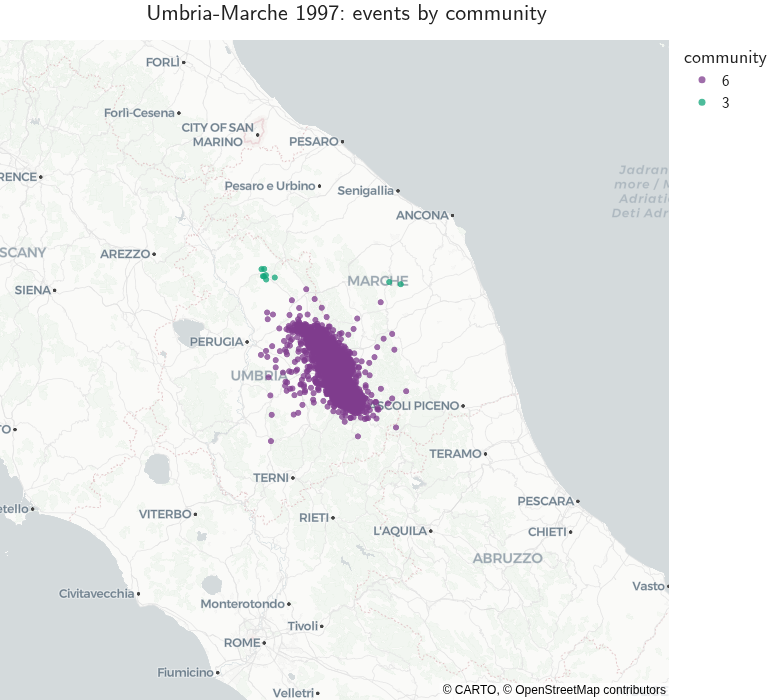

INFO  Saved results/figures/italy/known_eq/pdf/seq_l'aquila_louvain_italy_30km.pdf
INFO  Saved results/figures/italy/known_eq/jpg/seq_l'aquila_louvain_italy_30km.jpg


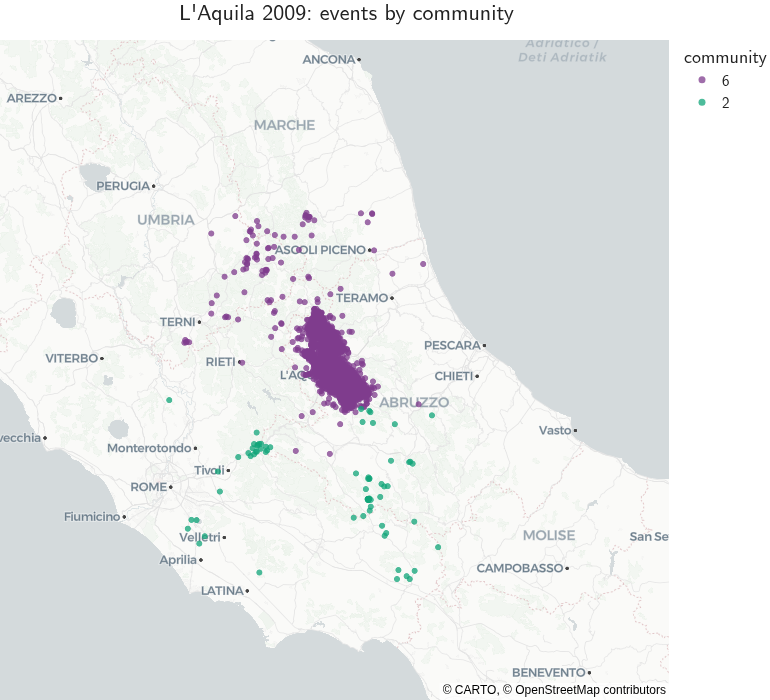

INFO  Saved results/figures/italy/known_eq/pdf/seq_emilia_louvain_italy_30km.pdf
INFO  Saved results/figures/italy/known_eq/jpg/seq_emilia_louvain_italy_30km.jpg


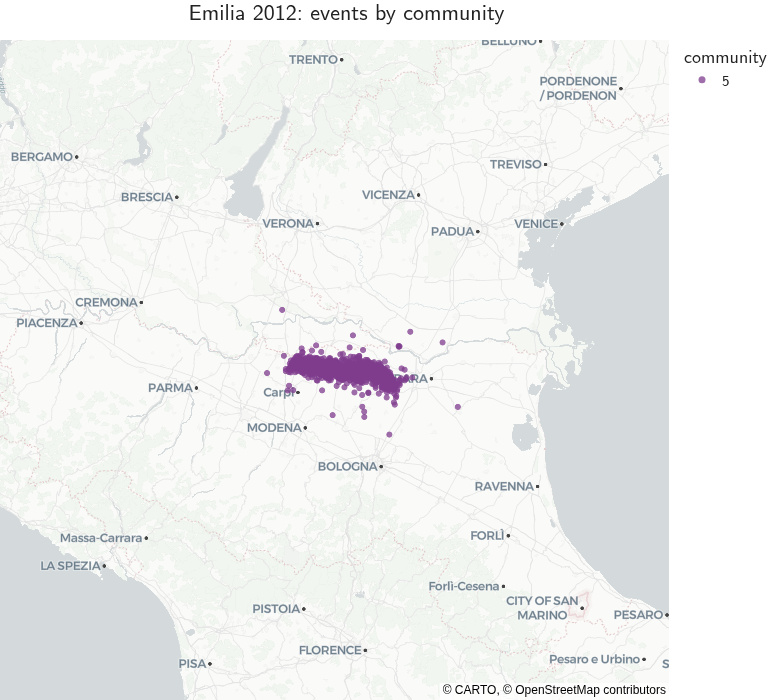

INFO  Saved results/figures/italy/known_eq/pdf/seq_amatrice-norcia_louvain_italy_30km.pdf
INFO  Saved results/figures/italy/known_eq/jpg/seq_amatrice-norcia_louvain_italy_30km.jpg


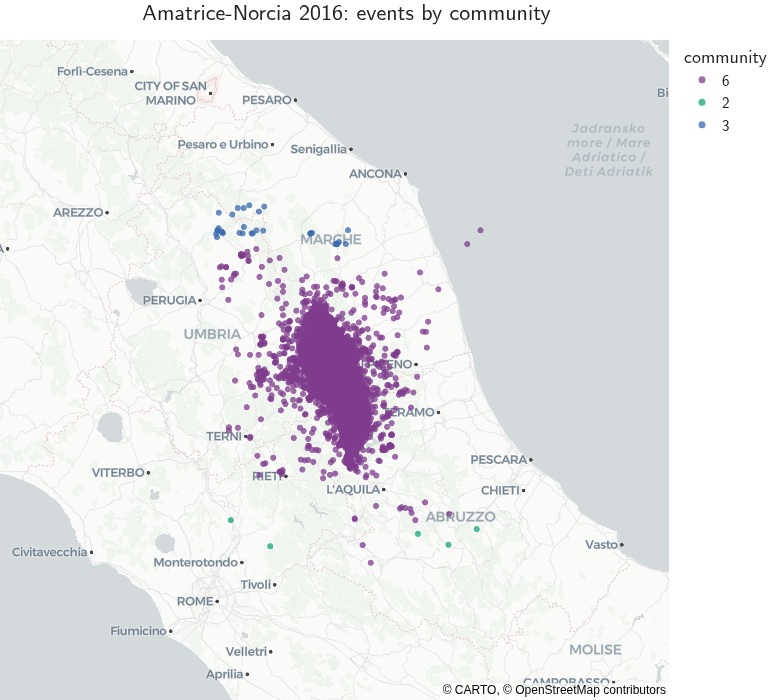

In [6]:
cmap_louvain = partitions["Louvain"]
for s in SEQUENCES:
    plot_sequence_community_geo(
        df_grid, cmap_louvain, s["name"],
        title=NET_LABEL, method_name="Louvain (directed)",
        zoom=7, height=MAP_HEIGHT, width=MAP_WIDTH,
        save_name=f"seq_{s['name'].split()[0].lower()}_louvain_{NET_TAG}",
        renderer="png",
    )

## Context – Full Community Map

The full directed-Louvain map for reference: the recovered sequence communities above are
sub-regions of it, showing whether known sequences are whole communities or dense cores.

INFO  Saved results/figures/italy/known_eq/pdf/community_geo_hybrid_louvain_directed_.pdf
INFO  Saved results/figures/italy/known_eq/jpg/community_geo_hybrid_louvain_directed_.jpg


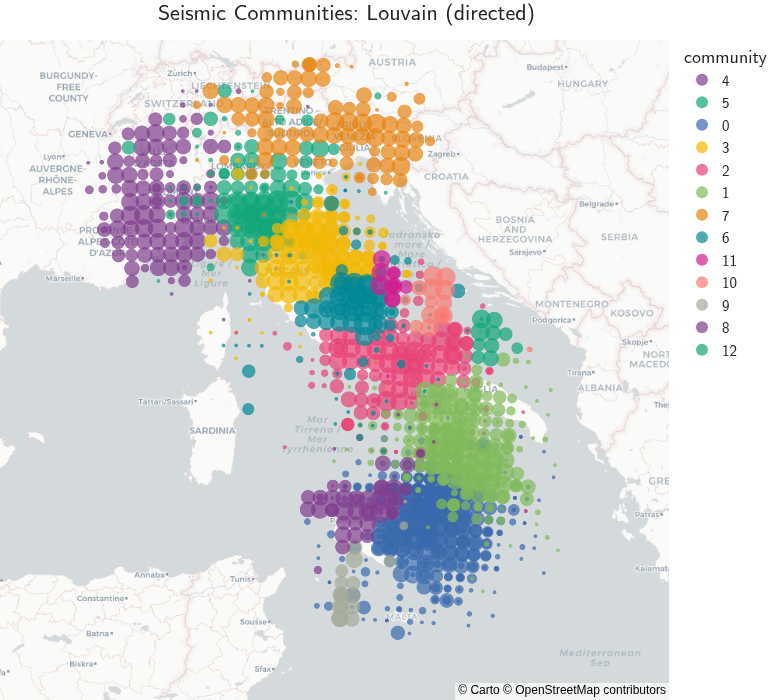

In [7]:
plot_community_geo_hybrid(
    G_giant, cmap_louvain,
    title=NET_LABEL,
    center_lat=41.9, center_lon=12.5, zoom=0,
    height=MAP_HEIGHT, width=MAP_WIDTH, bounds=_IT_BOUNDS,
    min_community_size=10, method_name="Louvain (directed)",
    renderer="png",
)